# Performing MJO filtering in 4 steps=>

📁 STEP 0: Setup folders

In [1]:
import os

base_dir = r"D:\PHD IIT KGP\6.MJO_FILTER"

folders = [
    "01_raw_combined",
    "02_mm_day",
    "03_region_mean",
    "04_climatology",
    "05_anomaly",
    "06_detrended",
    "07_bandpass",
    "08_standardized",
    "09_rmm",
    "10_composites"
]

for f in folders:
    os.makedirs(os.path.join(base_dir, f), exist_ok=True)

print("Folders created")

Folders created


🌧️ STEP 1: Load & Combine 45 years

In [2]:
import xarray as xr
import glob

files = sorted(glob.glob(r"D:\PHD IIT KGP\5.ERA5_1980-2025_12Months_DailyPrep_unzipped\*.nc"))

ds = xr.open_mfdataset(files, combine='by_coords')

ds.to_netcdf(os.path.join(base_dir, "01_raw_combined", "tp_combined.nc"))

: 

## The above Combination is done, not by this particular code

In [2]:
import xarray as xr

file = r"d:\PHD IIT KGP\6.MJO_FILTER\01_raw_combined\tp_combined.nc"

ds = xr.open_dataset(
    file,
    chunks={"time": 365, "latitude": 100, "longitude": 100}
)

print(ds)

<xarray.Dataset> Size: 27GB
Dimensions:    (time: 16802, latitude: 501, longitude: 801)
Coordinates:
  * time       (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
  * latitude   (latitude) float64 4kB 50.0 49.9 49.8 49.7 ... 0.3 0.2 0.1 0.0
  * longitude  (longitude) float64 6kB 40.0 40.1 40.2 40.3 ... 119.8 119.9 120.0
    number     int64 8B ...
    expver     (time) <U4 269kB dask.array<chunksize=(365,), meta=np.ndarray>
Data variables:
    tp         (time, latitude, longitude) float32 27GB dask.array<chunksize=(365, 100, 100), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T08:46 GRIB to CDM+CF via cfgrib-0.9.1...


📅 STEP 2: Daily Climatology (FULL GRID)

In [ ]:
ds = xr.open_dataset(
    file,
    chunks={"time": -1, "latitude": 100, "longitude": 100}
)

clim = ds['tp'].groupby('time.dayofyear').mean('time')

In [3]:
import xarray as xr
from dask.diagnostics import ProgressBar

# ============================================
# PATHS
# ============================================

input_file  = r"D:\PHD IIT KGP\6.MJO_FILTER\01_raw_combined\tp_combined.nc"
output_file = r"D:\PHD IIT KGP\6.MJO_FILTER\04_climatology\climatology.nc"

# ============================================
# LOAD DATA (SAFE CHUNKING)
# ============================================

ds = xr.open_dataset(
    input_file,
    chunks={
        "time": 20,
        "latitude": 40,
        "longitude": 40
    }
)

# ============================================
# REGION SELECTION
# ============================================

north, west, south, east = 50, 40, 0, 120

# Check latitude order once (important)
if ds.latitude[0] > ds.latitude[-1]:
    ds = ds.sel(latitude=slice(north, south), longitude=slice(west, east))
else:
    ds = ds.sel(latitude=slice(south, north), longitude=slice(west, east))

# ============================================
# MEMORY OPTIMIZATION
# ============================================

tp = ds['tp'].astype('float32')

# ============================================
# CLIMATOLOGY (LAZY)
# ============================================

clim = tp.groupby('time.dayofyear').mean('time', skipna=True)

# ============================================
# PROGRESS BAR + SAVE
# ============================================

print("🚀 Starting computation...")

with ProgressBar():
    clim.to_netcdf(output_file, compute=True)

print("✅ Done! Climatology saved.")

🚀 Starting computation...
[########################################] | 100% Completed | 42m 19s
✅ Done! Climatology saved.


⚡ STEP 3: Anomaly (GRID-WISE)

In [4]:
import xarray as xr
from dask.diagnostics import ProgressBar

# ============================================
# PATHS
# ============================================

input_file   = r"D:\PHD IIT KGP\6.MJO_FILTER\01_raw_combined\tp_combined.nc"
clim_file    = r"D:\PHD IIT KGP\6.MJO_FILTER\04_climatology\climatology.nc"
output_file  = r"D:\PHD IIT KGP\6.MJO_FILTER\05_anomaly\tp_anomaly.nc"

# ============================================
# LOAD DATA (SAFE CHUNKING)
# ============================================

ds = xr.open_dataset(
    input_file,
    chunks={"time": 20, "latitude": 40, "longitude": 40}
)

clim = xr.open_dataset(clim_file)

# ============================================
# REGION SELECTION (same as before!)
# ============================================

north, west, south, east = 50, 40, 0, 120

if ds.latitude[0] > ds.latitude[-1]:
    ds = ds.sel(latitude=slice(north, south), longitude=slice(west, east))
else:
    ds = ds.sel(latitude=slice(south, north), longitude=slice(west, east))

# ============================================
# MEMORY OPTIMIZATION
# ============================================

tp = ds['tp'].astype('float32')

# ============================================
# ANOMALY CALCULATION
# ============================================

anom = tp.groupby('time.dayofyear') - clim['tp']

# ============================================
# SAVE WITH PROGRESS BAR
# ============================================

print("🚀 Computing anomalies...")

with ProgressBar():
    anom.to_netcdf(output_file, compute=True)

print("✅ Anomaly file saved!")

🚀 Computing anomalies...
[                                        ] | 0% Completed | 93m 12ss


MemoryError: 

# Unsuccessfull proccess above !!

# Trying a second approach=>

## STEP 1: Configuring raw files 

In [1]:
import xarray as xr
import os

input_folder = r"D:\PHD 2025~\PHD\5.ERA5_1980-2025_12Months_DailyPrep_unzipped"
output_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\00_raw"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.endswith(".nc"):
        print(f"Processing: {file}")
        
        ds = xr.open_dataset(os.path.join(input_folder, file), chunks={"valid_time": 50})
        
        # Convert to mm
        tp = ds['tp'] * 1000
        
        # Create dayofyear coordinate
        tp = tp.assign_coords(dayofyear=ds['valid_time'].dt.dayofyear)
        
        # Replace dimension
        tp = tp.swap_dims({'valid_time': 'dayofyear'})
        
        # Drop old time
        tp = tp.drop_vars('valid_time')
        
        # Sort (important for consistency)
        tp = tp.sortby('dayofyear')
        
        # Convert to dataset
        tp_ds = tp.to_dataset(name='tp')
        
        # Save
        out_path = os.path.join(output_folder, file)
        tp_ds.to_netcdf(out_path)
        
print("✅ All files converted to dayofyear format")

Processing: ERA5_Land_Rainfall_1980.nc


C:\Users\hp\AppData\Local\Temp\ipykernel_2712\2845657031.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(os.path.join(input_folder, file), chunks={"valid_time": 50})


Processing: ERA5_Land_Rainfall_1981.nc


C:\Users\hp\AppData\Local\Temp\ipykernel_2712\2845657031.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(os.path.join(input_folder, file), chunks={"valid_time": 50})


Processing: ERA5_Land_Rainfall_1982.nc


...

Processing: ERA5_Land_Rainfall_2024.nc


C:\Users\hp\AppData\Local\Temp\ipykernel_2712\2845657031.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(os.path.join(input_folder, file), chunks={"valid_time": 50})


Processing: ERA5_Land_Rainfall_2025.nc


C:\Users\hp\AppData\Local\Temp\ipykernel_2712\2845657031.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(os.path.join(input_folder, file), chunks={"valid_time": 50})


✅ All files converted to dayofyear format


## ✅ CODE 2 (ANOMALY GENERATION, MEMORY SAFE)

In [2]:
import xarray as xr
import os

# Paths
raw_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\00_raw"
clim_file = r"D:\PHD 2025~\PHD\6.MJO_FILTER\04_climatology\climatology.nc"
output_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly"

os.makedirs(output_folder, exist_ok=True)

# Load climatology (chunked)
clim = xr.open_dataset(clim_file, chunks={"dayofyear": 50})

for file in os.listdir(raw_folder):
    if file.endswith(".nc"):
        print(f"Computing anomaly: {file}")
        
        ds = xr.open_dataset(os.path.join(raw_folder, file), chunks={"dayofyear": 50})
        
        # Align coordinates (VERY IMPORTANT)
        ds, clim_aligned = xr.align(ds, clim, join='exact')
        
        # Compute anomaly
        anomaly = ds['tp'] - clim_aligned['tp']
        
        anomaly_ds = anomaly.to_dataset(name='tp_anomaly')
        
        # Save
        out_path = os.path.join(output_folder, f"anom_{file}")
        anomaly_ds.to_netcdf(out_path)
        
print("✅ All anomaly files created")

Computing anomaly: ERA5_Land_Rainfall_1980.nc
Computing anomaly: ERA5_Land_Rainfall_1981.nc


AlignmentError: cannot align objects with join='exact' where index/labels/sizes are not equal along these coordinates (dimensions): 'dayofyear' ('dayofyear',)

In [3]:
import xarray as xr
import os

# ============================================
# PATHS
# ============================================

raw_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\00_raw"
clim_file = r"D:\PHD 2025~\PHD\6.MJO_FILTER\04_climatology\climatology.nc"
output_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly"

os.makedirs(output_folder, exist_ok=True)

# ============================================
# LOAD CLIMATOLOGY (CHUNKED)
# ============================================

clim = xr.open_dataset(clim_file, chunks={"dayofyear": 50})

# OPTIONAL (recommended for strict consistency)
# Remove leap day if needed
# clim = clim.sel(dayofyear=slice(1, 365))

# ============================================
# LOOP THROUGH FILES
# ============================================

for file in os.listdir(raw_folder):
    if file.endswith(".nc"):
        print(f"Computing anomaly: {file}")
        
        ds = xr.open_dataset(os.path.join(raw_folder, file), chunks={"dayofyear": 50})
        
        # ============================================
        # DEBUG CHECK (VERY IMPORTANT)
        # ============================================
        
        print(f"Raw days: {len(ds['dayofyear'])}, Clim days: {len(clim['dayofyear'])}")
        
        # ============================================
        # ALIGN (LEAP YEAR SAFE FIX)
        # ============================================
        
        ds_aligned, clim_aligned = xr.align(ds, clim, join='inner')
        
        # ============================================
        # COMPUTE ANOMALY
        # ============================================
        
        anomaly = ds_aligned['tp'] - clim_aligned['tp']
        
        anomaly_ds = anomaly.to_dataset(name='tp_anomaly')
        
        # ============================================
        # SAVE FILE
        # ============================================
        
        out_path = os.path.join(output_folder, f"anom_{file}")
        anomaly_ds.to_netcdf(out_path)
        
print("✅ STEP 2 DONE: All anomaly files created")

Computing anomaly: ERA5_Land_Rainfall_1980.nc
Raw days: 366, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1981.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1982.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1983.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1984.nc
Raw days: 366, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1985.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1986.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1987.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1988.nc
Raw days: 366, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1989.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1990.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1991.nc
Raw days: 365, Clim days: 366
Computing anomaly: ERA5_Land_Rainfall_1992.nc
Raw days: 366, Clim days: 366
Computing an

# Checking wheather the anomaly files are correctly created or not=>

In [4]:
import xarray as xr

# Files
raw_file   = r"D:\PHD 2025~\PHD\6.MJO_FILTER\00_raw\ERA5_Land_Rainfall_1991.nc"
clim_file  = r"D:\PHD 2025~\PHD\6.MJO_FILTER\04_climatology\climatology.nc"
anom_file  = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly\anom_ERA5_Land_Rainfall_1991.nc"

# Load
raw  = xr.open_dataset(raw_file)
clim = xr.open_dataset(clim_file)
anom = xr.open_dataset(anom_file)

# Pick a point
lat_val = 25
lon_val = 80
day = 200

# Extract values
raw_val  = raw['tp'].sel(latitude=lat_val, longitude=lon_val, method='nearest').isel(dayofyear=day).values
clim_val = clim['tp'].sel(latitude=lat_val, longitude=lon_val, method='nearest').isel(dayofyear=day).values
anom_val = anom['tp_anomaly'].sel(latitude=lat_val, longitude=lon_val, method='nearest').isel(dayofyear=day).values

print("\n🔍 MANUAL CHECK:")
print(f"Raw        : {raw_val}")
print(f"Climatology: {clim_val}")
print(f"Expected   : {raw_val - clim_val}")
print(f"Anomaly    : {anom_val}")


🔍 MANUAL CHECK:
Raw        : 32.20444869995117
Climatology: 11.139530181884766
Expected   : 21.064918518066406
Anomaly    : 21.064918518066406


# ALL Anomally file seems correct!!

# Removing low frequency variability with 120 days runing mean(DRM) => ENSO, seasonal leakage removed=>

In [6]:
import xarray as xr
import os
import pandas as pd

# ============================================
# PATHS
# ============================================

input_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly"
output_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\06_ENSO removed 120DRM"

os.makedirs(output_folder, exist_ok=True)

# ============================================
# LOOP THROUGH FILES
# ============================================

for file in os.listdir(input_folder):
    if file.endswith(".nc"):
        print(f"Processing: {file}")
        
        ds = xr.open_dataset(os.path.join(input_folder, file))
        
        anom = ds['tp_anomaly']
        
        # ============================================
        # REMOVE LOW-FREQUENCY (120-DAY RUNNING MEAN)
        # ============================================
        
        low_freq = anom.rolling(dayofyear=120, center=True).mean()
        anom_clean = anom - low_freq
        
        # Drop NaNs from rolling edges
        anom_clean = anom_clean.dropna(dim='dayofyear')
        
        # ============================================
        # FIX STRUCTURE (CRITICAL FIX)
        # ============================================
        
        # Rename dimension → CF-compliant
        anom_clean = anom_clean.rename({'dayofyear': 'time'})
        
        # Remove hidden coordinate conflicts
        anom_clean = anom_clean.reset_coords(drop=True)
        
        # OPTIONAL: Assign proper datetime axis (recommended)
        n = anom_clean.sizes['time']
        anom_clean = anom_clean.assign_coords(
            time=pd.date_range("2000-01-01", periods=n)
        )
        
        # Convert to dataset
        anom_clean_ds = anom_clean.to_dataset(name='tp_anomaly')
        
        # ============================================
        # SAVE
        # ============================================
        
        out_path = os.path.join(output_folder, f"clean_{file}")
        
        anom_clean_ds.to_netcdf(out_path)
        
print("✅ Step 5 completed successfully!")

Processing: anom_ERA5_Land_Rainfall_1980.nc
Processing: anom_ERA5_Land_Rainfall_1981.nc
Processing: anom_ERA5_Land_Rainfall_1982.nc
Processing: anom_ERA5_Land_Rainfall_1983.nc
Processing: anom_ERA5_Land_Rainfall_1984.nc
Processing: anom_ERA5_Land_Rainfall_1985.nc
Processing: anom_ERA5_Land_Rainfall_1986.nc
Processing: anom_ERA5_Land_Rainfall_1987.nc
Processing: anom_ERA5_Land_Rainfall_1988.nc
Processing: anom_ERA5_Land_Rainfall_1989.nc
Processing: anom_ERA5_Land_Rainfall_1990.nc
Processing: anom_ERA5_Land_Rainfall_1991.nc
Processing: anom_ERA5_Land_Rainfall_1992.nc
Processing: anom_ERA5_Land_Rainfall_1993.nc
Processing: anom_ERA5_Land_Rainfall_1994.nc
Processing: anom_ERA5_Land_Rainfall_1995.nc
Processing: anom_ERA5_Land_Rainfall_1996.nc
Processing: anom_ERA5_Land_Rainfall_1997.nc
Processing: anom_ERA5_Land_Rainfall_1998.nc
Processing: anom_ERA5_Land_Rainfall_1999.nc
Processing: anom_ERA5_Land_Rainfall_2000.nc
Processing: anom_ERA5_Land_Rainfall_2001.nc
Processing: anom_ERA5_Land_Rainf

# Failed the 120 day running mean!!

# Applying Lanczos filtering=>

In [8]:
import xarray as xr
import numpy as np
import os
import pandas as pd

# ============================================
# PATHS
# ============================================

input_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly"
output_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\06_MJO_LANCZOS"

os.makedirs(output_folder, exist_ok=True)

# ============================================
# LANCZOS FILTER FUNCTION
# ============================================

def lanczos_weights(window, cutoff_low, cutoff_high, dt=1):
    """
    Create Lanczos bandpass filter weights
    cutoff_low  = 1/100 (low freq)
    cutoff_high = 1/20  (high freq)
    """

    n = (window - 1) // 2
    k = np.arange(-n, n+1)

    sigma = np.sinc(k / n)

    # High-pass (remove >100 days)
    h_low = 2 * cutoff_low * np.sinc(2 * cutoff_low * k)

    # Low-pass (remove <20 days)
    h_high = 2 * cutoff_high * np.sinc(2 * cutoff_high * k)

    # Bandpass
    h = (h_high - h_low) * sigma

    return h

# ============================================
# FILTER PARAMETERS
# ============================================

window = 121   # must be odd
cutoff_low  = 1/100   # remove >100 days
cutoff_high = 1/20    # remove <20 days

weights = lanczos_weights(window, cutoff_low, cutoff_high)

# ============================================
# PROCESS FILES
# ============================================

for file in os.listdir(input_folder):
    if file.endswith(".nc"):
        print(f"Filtering: {file}")
        
        ds = xr.open_dataset(os.path.join(input_folder, file))
        
        anom = ds['tp_anomaly']

        # ============================================
        # CREATE TIME AXIS (FIXED)
        # ============================================

        n = anom.sizes['dayofyear']

        time = pd.date_range("2000-01-01", periods=n)

        # Attach time TO EXISTING dimension
        anom = anom.assign_coords(dayofyear=time)

        # Now rename dimension
        anom = anom.rename({'dayofyear': 'time'})
        
        # # ============================================
        # # CREATE TIME AXIS
        # # ============================================
        
        # n = anom.sizes['dayofyear']
        
        # anom = anom.assign_coords(
        #     time=pd.date_range("2000-01-01", periods=n)
        # )
        
        # anom = anom.swap_dims({'dayofyear': 'time'})
        # anom = anom.drop_vars('dayofyear')
        
        # ============================================
        # APPLY LANCZOS FILTER (CONVOLUTION)
        # ============================================
        
        mjo = xr.apply_ufunc(
            np.convolve,
            anom,
            weights,
            input_core_dims=[['time'], ['window']],
            output_core_dims=[['time']],
            vectorize=True,
            kwargs={'mode': 'same'},
            dask='parallelized',
            output_dtypes=[anom.dtype]
        )
        
        # ============================================
        # REMOVE EDGE EFFECTS
        # ============================================
        
        edge = window // 2
        mjo = mjo.isel(time=slice(edge, -edge))
        
        # ============================================
        # SAVE
        # ============================================
        
        mjo_ds = mjo.to_dataset(name='tp_mjo')
        
        out_path = os.path.join(output_folder, f"mjo_{file}")
        
        mjo_ds.to_netcdf(out_path)
        
print("✅ Lanczos MJO filtering completed!")

Filtering: anom_ERA5_Land_Rainfall_1980.nc
Filtering: anom_ERA5_Land_Rainfall_1981.nc
Filtering: anom_ERA5_Land_Rainfall_1982.nc
Filtering: anom_ERA5_Land_Rainfall_1983.nc
Filtering: anom_ERA5_Land_Rainfall_1984.nc
Filtering: anom_ERA5_Land_Rainfall_1985.nc
Filtering: anom_ERA5_Land_Rainfall_1986.nc
Filtering: anom_ERA5_Land_Rainfall_1987.nc
Filtering: anom_ERA5_Land_Rainfall_1988.nc
Filtering: anom_ERA5_Land_Rainfall_1989.nc
Filtering: anom_ERA5_Land_Rainfall_1990.nc
Filtering: anom_ERA5_Land_Rainfall_1991.nc
Filtering: anom_ERA5_Land_Rainfall_1992.nc
Filtering: anom_ERA5_Land_Rainfall_1993.nc
Filtering: anom_ERA5_Land_Rainfall_1994.nc
Filtering: anom_ERA5_Land_Rainfall_1995.nc
Filtering: anom_ERA5_Land_Rainfall_1996.nc
Filtering: anom_ERA5_Land_Rainfall_1997.nc
Filtering: anom_ERA5_Land_Rainfall_1998.nc
Filtering: anom_ERA5_Land_Rainfall_1999.nc
Filtering: anom_ERA5_Land_Rainfall_2000.nc
Filtering: anom_ERA5_Land_Rainfall_2001.nc
Filtering: anom_ERA5_Land_Rainfall_2002.nc
Filtering: 

# LEVEL 1: VISUAL TIME SERIES CHECK

In [9]:
import xarray as xr
import matplotlib.pyplot as plt

# Load files
anom_file = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly\anom_1991.nc"
mjo_file  = r"D:\PHD 2025~\PHD\6.MJO_FILTER\06_MJO_LANCZOS\mjo_anom_1991.nc"

anom = xr.open_dataset(anom_file)['tp_anomaly']
mjo  = xr.open_dataset(mjo_file)['tp_mjo']

# Fix time axis (same as before)
import pandas as pd
n = anom.sizes['dayofyear']
time = pd.date_range("2000-01-01", periods=n)

anom = anom.assign_coords(dayofyear=time).rename({'dayofyear': 'time'})
mjo  = mjo  # already has time

# Select point
lat, lon = 25, 80

ts_anom = anom.sel(latitude=lat, longitude=lon, method='nearest')
ts_mjo  = mjo.sel(latitude=lat, longitude=lon, method='nearest')

# Plot
plt.figure(figsize=(10,4))
ts_anom.plot(label='Anomaly', alpha=0.5)
ts_mjo.plot(label='MJO filtered', linewidth=2)
plt.legend()
plt.title("Time Series Check")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\PHD 2025~\\PHD\\6.MJO_FILTER\\05_anomaly\\anom_1991.nc'

Available anomaly files: ['anom_ERA5_Land_Rainfall_1980.nc', 'anom_ERA5_Land_Rainfall_1981.nc', 'anom_ERA5_Land_Rainfall_1982.nc']
Available MJO files: ['mjo_anom_ERA5_Land_Rainfall_1980.nc', 'mjo_anom_ERA5_Land_Rainfall_1981.nc', 'mjo_anom_ERA5_Land_Rainfall_1982.nc']

Using files:
D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly\anom_ERA5_Land_Rainfall_1980.nc
D:\PHD 2025~\PHD\6.MJO_FILTER\06_MJO_LANCZOS\mjo_anom_ERA5_Land_Rainfall_1980.nc


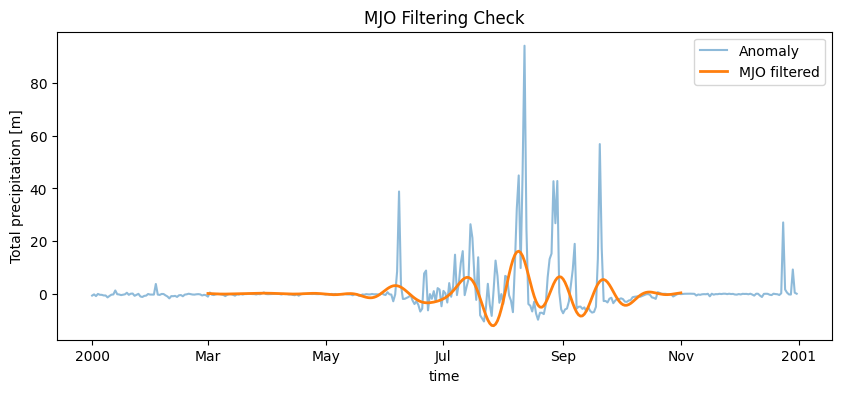

In [10]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# AUTO PICK FILE
# ============================================

anom_folder = r"D:\PHD 2025~\PHD\6.MJO_FILTER\05_anomaly"
mjo_folder  = r"D:\PHD 2025~\PHD\6.MJO_FILTER\06_MJO_LANCZOS"

anom_files = sorted([f for f in os.listdir(anom_folder) if f.endswith(".nc")])
mjo_files  = sorted([f for f in os.listdir(mjo_folder) if f.endswith(".nc")])

print("Available anomaly files:", anom_files[:3])
print("Available MJO files:", mjo_files[:3])

# Pick first file
anom_file = os.path.join(anom_folder, anom_files[0])
mjo_file  = os.path.join(mjo_folder,  mjo_files[0])

print("\nUsing files:")
print(anom_file)
print(mjo_file)

# ============================================
# LOAD DATA
# ============================================

anom = xr.open_dataset(anom_file)['tp_anomaly']
mjo  = xr.open_dataset(mjo_file)['tp_mjo']

# ============================================
# FIX TIME AXIS
# ============================================

n = anom.sizes['dayofyear']
time = pd.date_range("2000-01-01", periods=n)

anom = anom.assign_coords(dayofyear=time).rename({'dayofyear': 'time'})

# ============================================
# PICK GRID POINT
# ============================================

lat, lon = 25, 80

ts_anom = anom.sel(latitude=lat, longitude=lon, method='nearest')
ts_mjo  = mjo.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(10,4))
ts_anom.plot(label='Anomaly', alpha=0.5)
ts_mjo.plot(label='MJO filtered', linewidth=2)
plt.legend()
plt.title("MJO Filtering Check")
plt.show()